# RUSH policy convergence: interactive simulation and proof of concept

Companion notebook to the RUSH Technical Design Document (v0.5, Sections 5.10 to 5.12, X10, X11).
It does four things:

1. **Formalizes** policy convergence and label corruption with the notation of Section 5.11.
2. **Simulates** textual policy gradient descent on a 2D binary world with a multi-judge panel, so every quantity (misalignment, consensus, gradient, anchor value, gate, honest benchmark) is computable and visible.
3. **Visualizes** the policy as an SVM-style decision boundary with contours, the descent trajectory in parameter space, convergence in a document vector space, the two corruption failure modes, and the Lyapunov probe.
4. **Loads real run exports** (clean versus corrupted arms) so the same plots run on live RUSH data.

Dependencies: numpy, pandas, matplotlib, scikit-learn. ipywidgets is optional (Section 8 degrades gracefully without it).

## 1. The formalism

**The optimizer as a stochastic map (C1).** One run is a trajectory of a stochastic discrete-time dynamical system on the space of policy documents:

$$G_{k+1} = \Phi(G_k,\ \xi_k) \tag{C1}$$

where $\xi_k$ collects the cycle stochasticity (seeded mini-batch draw, judge decoding, drafter decoding). On a gate skip, $\Phi$ is the identity; the settling time $\tau$ is the last accepted cycle.

**Two distances (C2).** With $\varphi$ a frozen document embedding of the canonical policy render and $P$ a fixed probe set:

$$d_{emb}(G, G') = \mathrm{dist}\big(\varphi(G), \varphi(G')\big), \qquad d_{beh}(G, G') = \frac{1}{N_P}\sum_{x \in P} \mathbf{1}\big[\hat{y}(x; G) \neq \hat{y}(x; G')\big] \tag{C2}$$

**Separation and the finite-time Lyapunov estimate (C3).** For a pair of runs separated by one controlled perturbation:

$$\delta_k = d(G_k, G'_k), \qquad \hat\lambda(k) = \frac{1}{k}\,\ln\frac{\delta_k}{\delta_0} \tag{C3}$$

estimated as the log-linear slope of $\ln\delta_k$ on the pre-saturation window. Regimes: $\hat\lambda < 0$ contraction (the data determines the policy, the path is forgotten), $\hat\lambda \approx 0$ neutral drift ($\delta_k \propto k^{1/2}$, pure diffusion), $\hat\lambda > 0$ operational chaos (the final policy is a seed artifact).

**Ensemble dispersion (C4).** Over $R$ replicates: $\ \sigma_k = \frac{2}{R(R-1)} \sum_{r < r'} d\big(G_k^{(r)}, G_k^{(r')}\big)$.

**Per-item signals (Sections 5.3 to 5.7).** Judge $j$ assigns credit $p_j = c_j$ if $\hat{y}_j = y$ else $1 - c_j$; the gradient magnitude is $|g_j| = 1 - p_j$ (confident-wrong $\approx 1$). Over decisive judges: SME agreement $a$, misalignment $m = 1 - a$, SME-blind consensus $\kappa$, base importance $I_{base} = \frac{m(1 + 2\kappa) + (1 - \kappa)}{3}$, amplifier $amp = (1 + \overline{|g|})(1 + \tfrac{1}{2}b)(1 + s_{blame})$, anchor value $I_{base}\cdot amp$.

### Label corruption, formalized (Section 5.12)

Corrupt each label in scope $S$ independently: $\tilde{y}_i = \zeta_i\, y_i$ with $P(\zeta_i = -1) = \rho$. Two failure channels, and they are not symmetric:

- **Case A, silencing (a missed learning opportunity).** A genuinely misaligned item ($m \approx 1$: the policy truly fails here) whose label flips now agrees with the panel: $\tilde{m} = 1 - m \approx 0$, so $I_{base} \to \approx 0$, per-judge credit becomes $p = c$ so $|g| \to 1 - c \approx 0$, and the anchor value collapses. The true gradient mass is removed; the loop never learns the correction.
- **Case B, adversarial injection (an incorrect learning opportunity).** A truly aligned item ($m \approx 0$, $\kappa$ high) whose label flips reads as $\tilde{m} \approx 1$ with $\kappa$ unchanged ($\kappa$ is SME-blind): a synthetic T1. Confident-wrong credit maximizes $\overline{|g|}$, so the amplifier is near its ceiling and the item lands at the top of the anchor queue. **Importance-weighted selection amplifies corruption by construction**: under greedy selection the corrupted share of the anchor set can far exceed $\rho$. The drafter then descends a corrupted objective, and the step direction decorrelates from the true gradient: chaotic descent, $\hat\lambda$ rises.

With base misalignment rate $m_0$, random corruption converts mass $\rho\, m_0$ into silence (Case A) and $\rho(1 - m_0)$ into adversarial anchors (Case B); since $m_0$ is usually well below one half, most corruption becomes Case B. In the wild, easy positives and easy negatives are rarely mislabeled: corruption concentrates on hard boundary items, so random corruption is the optimistic assumption and targeted corruption of T1/T2 and hard-aligned items is the stress case. Both are knobs below and in the run form (X11).

In [1]:
# 0. Setup
%matplotlib inline
import json, math, os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 105, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})
COL = {'clean': '#2563eb', 'c10': '#f59e0b', 'c20': '#e11d48', 'c50': '#7c3aed',
       'greedy': '#e11d48', 'pps': '#f59e0b', 'random': '#2563eb'}
print('setup ok')

setup ok


In [2]:
# 1. The world and the judge panel
def make_world(n=1200, seed=13, sep=1.5, spread=1.0):
    '''2D binary world. True boundary is x1 + x2 = 0; hardness = small |true margin|.'''
    rng = np.random.default_rng(seed)
    n2 = n // 2
    Xp = rng.normal([+sep / 2, +sep / 2], spread, size=(n2, 2))
    Xn = rng.normal([-sep / 2, -sep / 2], spread, size=(n2, 2))
    X = np.vstack([Xp, Xn]); y = np.hstack([np.ones(n2), -np.ones(n2)]).astype(int)
    idx = rng.permutation(n)
    return X[idx], y[idx]

class Panel:
    '''M cheap judges. Each reads the policy (w, b) imperfectly: a fixed personal
    rotation and bias, plus per-call decoding noise. Confidence from the margin.'''
    def __init__(self, M=5, temp=1.2, seed=0):
        rng = np.random.default_rng(seed)
        self.M = M; self.temp = temp
        self.rot   = rng.normal(0, 0.25, M)
        self.bias  = rng.normal(0, 0.25, M)
        self.noise = rng.uniform(0.30, 0.90, M)
    def votes(self, w, b, X, rng):
        ys, cs = [], []
        for j in range(self.M):
            ca, sa = math.cos(self.rot[j]), math.sin(self.rot[j])
            wj = np.array([ca * w[0] - sa * w[1], sa * w[0] + ca * w[1]])
            marg = X @ wj + b + self.bias[j] + rng.normal(0, self.noise[j], len(X))
            ys.append(np.where(marg >= 0, 1, -1))
            cs.append(1.0 / (1.0 + np.exp(-np.abs(marg) / self.temp)))
        return np.array(ys), np.array(cs)   # both (M, n)

def panel_stats(votes, conf, y_label):
    '''Per-item signals of Sections 5.3 to 5.7 (b and s_blame set to 0 in the sim).'''
    agree = votes == y_label[None, :]
    a = agree.mean(0); m = 1.0 - a
    pos = (votes == 1).mean(0)
    kappa = np.maximum(pos, 1.0 - pos)                       # SME-blind consensus
    p = np.where(agree, conf, 1.0 - conf); g = 1.0 - p       # per-judge credit and gradient
    gbar = g.mean(0)
    misal = m > 0.5
    hi = kappa >= 0.8                                        # strict consensus (4 of 5)
    tier = np.where(misal & hi, 1, np.where(misal, 2, np.where(~hi, 3, 4)))
    I = (m * (1 + 2 * kappa) + (1 - kappa)) / 3.0
    anchor = I * (1.0 + gbar)                                # amp with b = s_blame = 0
    return dict(a=a, m=m, kappa=kappa, gbar=gbar, tier=tier, I=I, anchor=anchor, misal=misal)

X_demo, y_demo = make_world()
pn = Panel(seed=0)
v, c = pn.votes(np.array([1.0, -0.30]), 0.0, X_demo, np.random.default_rng(1))
st = panel_stats(v, c, y_demo)
print('world n=%d | base misalignment m0=%.2f | tier shares:' % (len(y_demo), st['misal'].mean()),
      {t: round((st['tier'] == t).mean(), 2) for t in [1, 2, 3, 4]})

world n=1200 | base misalignment m0=0.33 | tier shares: {1: np.float64(0.21), 2: np.float64(0.11), 3: np.float64(0.12), 4: np.float64(0.56)}


In [3]:
# 2. Corruption operator and the RUSH-like optimizer
def corrupt(y_true, scope_idx, rho, target, st0, X, seed):
    '''Flip a fraction rho of labels inside scope. target: random | misaligned_t12 | hard_aligned.'''
    y = y_true.copy(); flip = np.zeros(len(y), bool)
    k = int(round(rho * len(scope_idx)))
    if k == 0: return y, flip
    rng = np.random.default_rng(seed)
    if target == 'random':
        pick = rng.choice(scope_idx, k, replace=False)
    elif target == 'misaligned_t12':                     # Case A mass: true T1/T2 items
        cand = scope_idx[st0['misal'][scope_idx]]
        order = cand[np.argsort(-st0['anchor'][cand])]
        pick = order[:k] if len(order) >= k else np.r_[order, rng.choice(scope_idx, k - len(order), replace=False)]
    else:                                                # hard_aligned: Case B mass near the boundary
        cand = scope_idx[~st0['misal'][scope_idx]]
        hard = cand[np.argsort(np.abs(X[cand].sum(1)))]  # small true margin first
        pick = hard[:k]
    y[pick] = -y[pick]; flip[pick] = True
    return y, flip

def macro_f1(w, b, X, y):
    pred = np.where(X @ w + b >= 0, 1, -1)
    return f1_score(y, pred, average='macro')

def run_descent(seed=13, K=22, N=60, T=200, A=8, rho=0.0, target='random', strategy='greedy',
                gate='metric', eps=0.0, clip=0.5, eta=0.9, w0=(1.0, -0.30), b0=0.0,
                M=5, world_seed=13, corrupt_gate=False, drafter_noise=0.04,
                panel_seed=0, corrupt_seed=None):
    '''One RUSH-like run. All stochastic draws come from one rng seeded by `seed` and are
    consumed in a fixed order regardless of accept/skip, so two runs with the same seed
    share the exact noise path xi (the D1 shadow-pair requirement).'''
    X, y_true = make_world(seed=world_seed)
    rng = np.random.default_rng(seed)
    perm = np.random.default_rng(world_seed + 777).permutation(len(X))
    bench, test, pool = perm[:T], perm[T:2 * T], perm[2 * T:]
    panel = Panel(M=M, seed=panel_seed)
    w = np.array(w0, float); b = float(b0)
    v0, c0 = panel.votes(w, b, X, np.random.default_rng(999))
    st0 = panel_stats(v0, c0, y_true)
    scope = np.r_[pool, test] if corrupt_gate else pool
    y_lab, flip = corrupt(y_true, scope, rho, target, st0, X,
                          seed if corrupt_seed is None else corrupt_seed)
    H = dict(k=[], w=[(w.copy(), b)], accepted=[], f1_test=[], f1_bench=[],
             step=[], ang=[], flip_share=[], g_anchor=[], text=[], anchor_pos=[])
    n_carve = 0
    H['text'].append(render_policy(w, b, 'v0.1', n_carve))
    f1_b0 = macro_f1(w, b, X[bench], y_true[bench])
    for k in range(1, K + 1):
        B = rng.choice(pool, N, replace=False)                       # xi: batch draw
        votes, conf = panel.votes(w, b, X[B], rng)                   # xi: judge decoding
        noise = rng.normal(0, drafter_noise, 2)                      # xi: drafter decoding
        st = panel_stats(votes, conf, y_lab[B])
        cand = np.where(st['misal'])[0]
        if len(cand) == 0:
            H['k'].append(k); H['accepted'].append(False); H['step'].append(0.0)
            H['ang'].append(np.nan); H['flip_share'].append(0.0); H['g_anchor'].append(0.0); H['anchor_pos'].append(np.nan)
            H['f1_test'].append(macro_f1(w, b, X[test], y_lab[test]))
            H['f1_bench'].append(macro_f1(w, b, X[bench], y_true[bench]))
            H['w'].append((w.copy(), b)); H['text'].append(H['text'][-1]); continue
        s = st['anchor'][cand]
        if strategy == 'greedy':
            sel = cand[np.argsort(-s)[:A]]
        else:
            pr = np.ones_like(s) if strategy == 'random' else s
            pr = pr / pr.sum()
            sel = rng.choice(cand, min(A, len(cand)), replace=False, p=pr)
        idx = B[sel]; xx, yy = X[idx], y_lab[idx]
        wgt = st['anchor'][sel]; wgt = wgt / wgt.sum()
        marg = xx @ w + b
        gc = -yy / (1.0 + np.exp(yy * marg))                         # logistic gradient
        dw = -eta * (wgt[:, None] * gc[:, None] * xx).sum(0) + noise
        db = -eta * float((wgt * gc).sum())
        nrm = math.sqrt(dw @ dw + db * db)
        if nrm > clip: dw, db = dw * clip / nrm, db * clip / nrm     # the edit clip / trust region
        w2, b2 = w + dw, b + db
        f1_old = macro_f1(w, b, X[test], y_lab[test])
        f1_new = macro_f1(w2, b2, X[test], y_lab[test])
        acc = (gate == 'off') or (f1_new > f1_old + eps)
        fs = float(flip[idx].mean())
        if acc:
            w, b = w2, b2
            if fs > 0.4: n_carve += 1                                # corruption-driven carve-out
        H['k'].append(k); H['accepted'].append(bool(acc))
        H['step'].append(float(np.linalg.norm(dw)) if acc else 0.0)
        H['ang'].append(math.degrees(math.atan2(dw[1], dw[0])))
        H['flip_share'].append(fs); H['g_anchor'].append(float(st['gbar'][sel].mean()))
        H['anchor_pos'].append(float((yy == 1).mean()))
        H['f1_test'].append(macro_f1(w, b, X[test], y_lab[test]))
        H['f1_bench'].append(macro_f1(w, b, X[bench], y_true[bench]))
        H['w'].append((w.copy(), b))
        H['text'].append(render_policy(w, b, 'v%d' % k, n_carve) if acc else H['text'][-1])
    H.update(X=X, y_true=y_true, y_lab=y_lab, flip=flip, bench=bench, test=test, pool=pool,
             f1_bench0=f1_b0, panel=panel, st0=st0)
    return H

def render_policy(w, b, ver, n_carve=0):
    '''A toy canonical policy render whose clauses move with the parameters, so a
    document vector space exists for the simulation too.'''
    th = math.degrees(math.atan2(w[1], w[0])); nrm = math.hypot(*w) + 1e-12
    L = ['POLICY %s' % ver,
         'root: an item is POSITIVE when the weighted evidence crosses the decision line.',
         'clause geometry.axis: weight feature_1 by %+.2f and feature_2 by %+.2f.' % (w[0], w[1]),
         'clause geometry.threshold: the signed margin must exceed %+.2f.' % (-b / nrm),
         'clause boundary.angle: the decision line sits at %.1f degrees.' % th]
    for i in range(n_carve):
        L.append('clause exception.%d: carve-out for the contested region %d flagged by the panel.' % (i + 1, i + 1))
    return chr(10).join(L)

print('optimizer ready')

optimizer ready


## 2. Baseline: the boundary as an SVM-style picture

The policy is a decision boundary. We draw the training scatter, the evolving policy line per cycle (colored by $k$), the final policy's decision-function contour, and a linear SVM fit on clean labels as the oracle reference. The right panel is the honest learning curve: gate-set F1 (what the gate sees) versus benchmark F1 on clean labels (what is true).

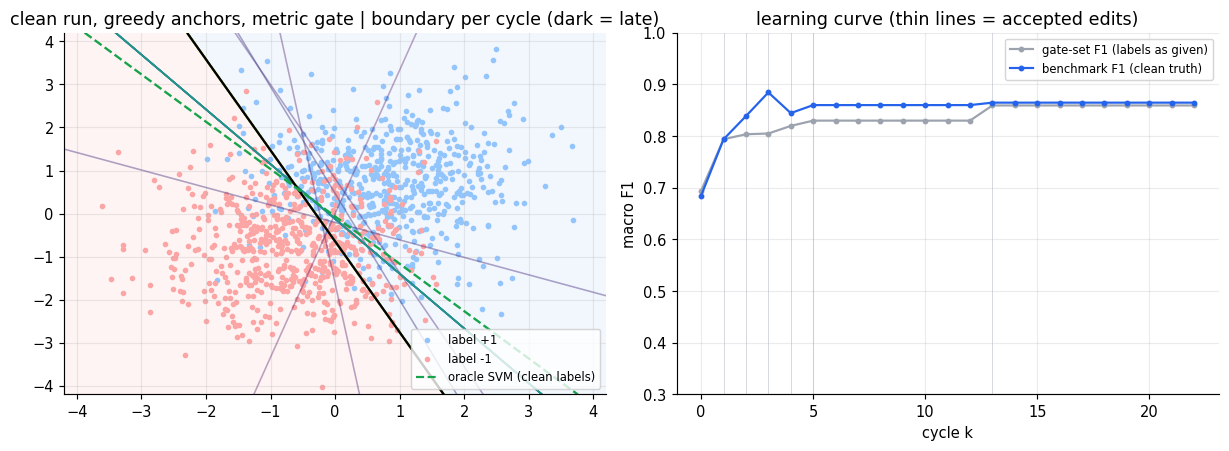

final benchmark F1 = 0.865 | accepted 6 / 22 | settling tau = 13


In [4]:
# 3. Clean baseline run and the SVM-style visualization
def draw_boundary(ax, w, b, **kw):
    xs = np.linspace(-4.2, 4.2, 2)
    if abs(w[1]) > 1e-9: ax.plot(xs, -(w[0] * xs + b) / w[1], **kw)

def plot_run(H, title, show_svm=True, flip_marks=True):
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
    ax = axes[0]
    X, y = H['X'], H['y_lab']
    ax.scatter(*X[y == 1].T, s=8, c='#93c5fd', label='label +1')
    ax.scatter(*X[y == -1].T, s=8, c='#fca5a5', label='label -1')
    if flip_marks and H['flip'].any():
        ax.scatter(*X[H['flip']].T, s=42, facecolors='none', edgecolors='k',
                   linewidths=0.9, label='flipped labels')
    n = len(H['w']); cmap = cm.viridis
    for i, (w, b) in enumerate(H['w']):
        draw_boundary(ax, w, b, color=cmap(i / max(n - 1, 1)), lw=1.1,
                      alpha=0.35 + 0.65 * i / max(n - 1, 1))
    wf, bf = H['w'][-1]
    gx, gy = np.meshgrid(np.linspace(-4.2, 4.2, 160), np.linspace(-4.2, 4.2, 160))
    Z = gx * wf[0] + gy * wf[1] + bf
    ax.contourf(gx, gy, Z, levels=[-99, 0, 99], colors=['#fee2e2', '#dbeafe'], alpha=0.35, zorder=0)
    ax.contour(gx, gy, Z, levels=[0], colors='k', linewidths=1.6)
    if show_svm:
        sv = SVC(kernel='linear', C=1.0).fit(H['X'], H['y_true'])
        Zs = sv.decision_function(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
        ax.contour(gx, gy, Zs, levels=[0], colors='#16a34a', linestyles='--', linewidths=1.6)
        ax.plot([], [], '--', c='#16a34a', label='oracle SVM (clean labels)')
    ax.set_xlim(-4.2, 4.2); ax.set_ylim(-4.2, 4.2)
    ax.set_title(title + ' | boundary per cycle (dark = late)')
    ax.legend(loc='lower right', fontsize=8)
    ax = axes[1]
    ks = [0] + H['k']
    ax.plot(ks, [macro_f1(*H['w'][0], H['X'][H['test']], H['y_lab'][H['test']])] + H['f1_test'],
            'o-', ms=3, c='#9ca3af', label='gate-set F1 (labels as given)')
    ax.plot(ks, [H['f1_bench0']] + H['f1_bench'], 'o-', ms=3, c=COL['clean'],
            label='benchmark F1 (clean truth)')
    for k, acc in zip(H['k'], H['accepted']):
        if acc: ax.axvline(k, color='#d1d5db', lw=0.6, zorder=0)
    ax.set_xlabel('cycle k'); ax.set_ylabel('macro F1'); ax.set_ylim(0.3, 1.0)
    ax.set_title('learning curve (thin lines = accepted edits)')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

H_clean = run_descent(rho=0.0)
plot_run(H_clean, 'clean run, greedy anchors, metric gate')
print('final benchmark F1 = %.3f | accepted %d / %d | settling tau = %d'
      % (H_clean['f1_bench'][-1], sum(H_clean['accepted']), len(H_clean['k']),
         max([k for k, a in zip(H_clean['k'], H_clean['accepted']) if a], default=0)))

## 3. Convergence in a document vector space: is $d_{emb}$ a good metric?

Every accepted version has a canonical text render, embedded here with TF-IDF character n-grams (a stand-in for the frozen embedding model $\varphi$; on real runs use the versioned embedder). Three facts the plot establishes, and the caveats that answer the question:

- $d_{emb}$ **tracks the descent**: consecutive-version distances shrink as the run settles, so it is a legitimate convergence instrument (step size in C-series notation).
- $d_{emb}$ **is only a pseudo-metric on behavior**: two parameter vectors $w$ and $2w$ define the same boundary ($d_{beh} = 0$) yet different texts and different Euclidean parameter distances. Behavioral equivalence classes are the real objects; cosine on normalized parameters fixes the scale case but not paraphrase in general.
- $d_{emb}$ **correlates with $d_{beh}$ but saturates**: past a point, very different texts are just "very different," while $d_{beh}$ keeps resolving. Verdict: a good cheap proxy for trajectory geometry (steps, $\delta_k$, dispersion), to be calibrated against and reported alongside $d_{beh}$, never a substitute for it. Embedding-model and render drift must be pinned or distance drift masquerades as policy drift.

w vs 2w: d_beh = 0.000 | Euclidean param dist = 0.53 | text cosine dist = 0.041


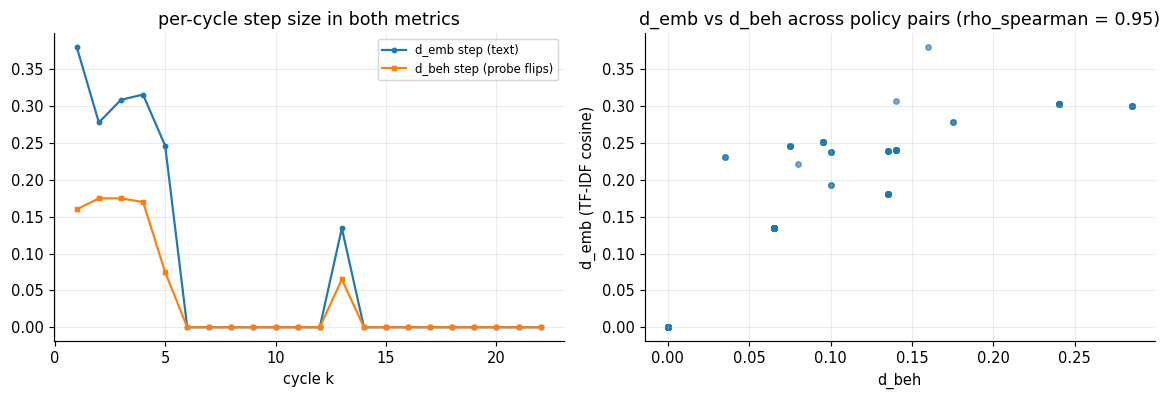

In [5]:
# 4. d_emb versus d_beh
def d_beh(w1, b1, w2, b2, Xp):
    p1 = np.where(Xp @ w1 + b1 >= 0, 1, -1); p2 = np.where(Xp @ w2 + b2 >= 0, 1, -1)
    return float((p1 != p2).mean())

def embed_texts(texts):
    tv = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))
    return tv.fit_transform(texts)

texts = H_clean['text']
E = embed_texts(texts)
D_emb_step = [cosine_distances(E[i], E[i + 1])[0, 0] for i in range(len(texts) - 1)]
Xp = H_clean['X'][H_clean['bench']]
D_beh_step = [d_beh(*H_clean['w'][i], *H_clean['w'][i + 1], Xp) for i in range(len(texts) - 1)]

# scale-invariance demo: same behavior, different document
w, b = H_clean['w'][-1]
tA, tB = render_policy(w, b, 'vA'), render_policy(2 * np.asarray(w), 2 * b, 'vB')
EE = embed_texts([tA, tB])
print('w vs 2w: d_beh = %.3f | Euclidean param dist = %.2f | text cosine dist = %.3f'
      % (d_beh(w, b, 2 * np.asarray(w), 2 * b, Xp), np.linalg.norm(np.asarray(w)),
         cosine_distances(EE[0], EE[1])[0, 0]))

# correlation across many random policy pairs
rng = np.random.default_rng(7)
pairs, de, db = [], [], []
Ws = [np.r_[np.asarray(wb[0]), wb[1]] for wb in H_clean['w']]
for _ in range(140):
    i, j = rng.integers(0, len(Ws), 2)
    de.append(cosine_distances(E[i], E[j])[0, 0])
    db.append(d_beh(Ws[i][:2], Ws[i][2], Ws[j][:2], Ws[j][2], Xp))
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.9))
axes[0].plot(range(1, len(D_emb_step) + 1), D_emb_step, 'o-', ms=3, label='d_emb step (text)')
axes[0].plot(range(1, len(D_beh_step) + 1), D_beh_step, 's-', ms=3, label='d_beh step (probe flips)')
axes[0].set_xlabel('cycle k'); axes[0].set_title('per-cycle step size in both metrics')
axes[0].legend(fontsize=8)
axes[1].scatter(db, de, s=14, alpha=0.6)
axes[1].set_xlabel('d_beh'); axes[1].set_ylabel('d_emb (TF-IDF cosine)')
axes[1].set_title('d_emb vs d_beh across policy pairs (rho_spearman = %.2f)'
                  % pd.Series(de).corr(pd.Series(db), method='spearman'))
plt.tight_layout(); plt.show()

## 4. Corruption experiments: 0 / 10 / 20 / 50 percent

Mirrors the run-form knob and X11. Sweep $\rho$ and the sampling strategy; every run gets the same seed and start. Read four things: the honest learning curve bends down with $\rho$; **the anchor corruption share sits far above $\rho$ under greedy selection** (Case B amplification); the accept rate and step behavior change; the rendered policy document grows as corruption-driven carve-outs accumulate.

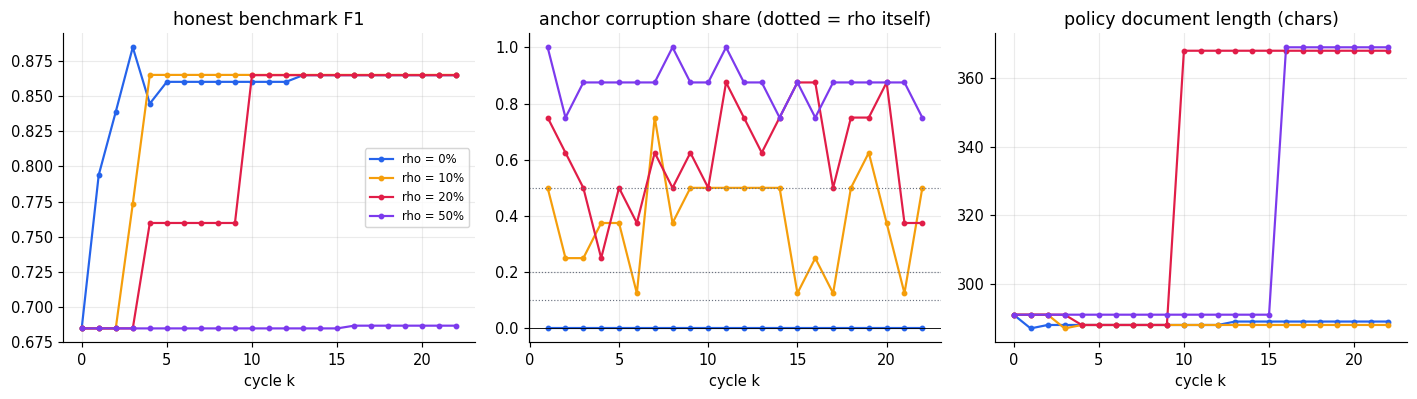

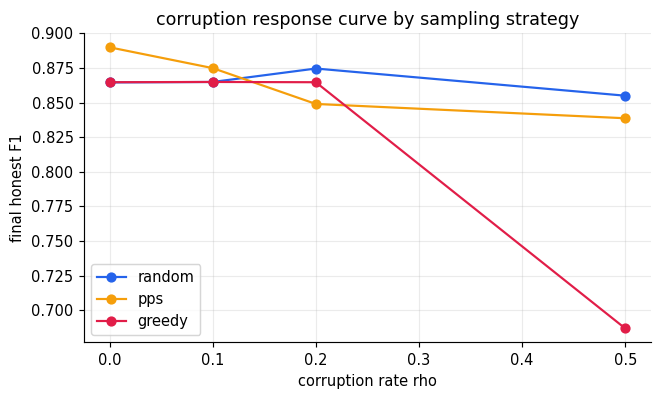

strategy,greedy,pps,random
rho,,,
0.0,0.00,0.00,0.00
0.1,0.39,0.34,0.31
0.2,0.62,0.53,0.52
0.5,0.87,0.65,0.64


In [6]:
# 5. The rho sweep
rhos = [0.0, 0.10, 0.20, 0.50]
keys = ['clean', 'c10', 'c20', 'c50']
runs = {kk: run_descent(rho=r, target='random', strategy='greedy') for kk, r in zip(keys, rhos)}

fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.9))
for kk, r in zip(keys, rhos):
    H = runs[kk]; ks = [0] + H['k']
    axes[0].plot(ks, [H['f1_bench0']] + H['f1_bench'], 'o-', ms=3, c=COL[kk],
                 label='rho = %.0f%%' % (100 * r))
    axes[1].plot(H['k'], np.array(H['flip_share']), 'o-', ms=3, c=COL[kk])
    axes[2].plot(ks, [len(t) for t in H['text']], 'o-', ms=3, c=COL[kk])
axes[0].set_title('honest benchmark F1'); axes[0].set_xlabel('cycle k'); axes[0].legend(fontsize=8)
axes[1].axhline(0, c='k', lw=0.6)
for r in rhos[1:]: axes[1].axhline(r, ls=':', lw=0.8, c='#6b7280')
axes[1].set_title('anchor corruption share (dotted = rho itself)'); axes[1].set_xlabel('cycle k')
axes[2].set_title('policy document length (chars)'); axes[2].set_xlabel('cycle k')
plt.tight_layout(); plt.show()

rows = []
for strat in ['random', 'pps', 'greedy']:
    for r in rhos:
        hh = run_descent(rho=r, strategy=strat)
        rows.append(dict(strategy=strat, rho=r, final_F1=hh['f1_bench'][-1],
                         anchor_flip_share=float(np.mean(hh['flip_share'])),
                         accepted=int(sum(hh['accepted']))))
df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(6.4, 3.9))
for strat in ['random', 'pps', 'greedy']:
    d = df[df.strategy == strat]
    ax.plot(d.rho, d.final_F1, 'o-', c=COL[strat], label=strat)
ax.set_xlabel('corruption rate rho'); ax.set_ylabel('final honest F1')
ax.set_title('corruption response curve by sampling strategy')
ax.legend(); plt.tight_layout(); plt.show()
df.pivot(index='rho', columns='strategy', values='anchor_flip_share').round(2)

## 5. The decision quality plane: gradient descent without the embedding

The parameter chart of Section 2 (angle $\\varphi = \\mathrm{atan2}(w_2, w_1)$, the orientation of the boundary normal; offset $d = -b/\\lVert w \\rVert$, the line's distance from the origin) exists only because the toy policy is a line. Real policies have no such chart. But every policy, text or otherwise, maps to a point on the **decision quality plane**: $x$ = true negative rate, $y$ = true positive rate. The corner $(1, 1)$ is perfection, the gap components are exactly $(FNR, FPR)$, the two errors the DQ objective minimizes, and macro F1 and balanced accuracy are contour families on the square. The distance to the corner is the loss; no separate offset coordinate is needed, it is derived.

The axes carry the learning semantics directly: motion along the TPR axis is driven by anchors labeled positive (misaligned false negatives mostly, plus a little reinforcement from aligned true positives, the X2 mix), and motion along TNR by anchors labeled negative. Corruption becomes geometry. With uniform flips at rate $q$ among what the loop actually trains on, and balanced prevalence:

$$\\widetilde{TPR} = (1 - q)\\,TPR + q\\,(1 - TNR), \\qquad \\widetilde{BAcc} = q + (1 - 2q)\\,BAcc \\tag{C5}$$

Three consequences. **The optimum does not move** under uniform symmetric corruption; the plane is sheared toward the coin-flip anti-diagonal $TPR + TNR = 1$, which is the fixed set of the map. **Every gradient shrinks by $(1 - 2q)$** and reverses sign past $q = 1/2$. And critically, $q$ **is not the injected rate** $\\rho$: it is the corrupted share of the anchor set, and greedy importance selection amplifies it (measured in Section 4: $q \\approx 0.46,\\ 0.74,\\ 0.96$ at $\\rho = 0.1,\\ 0.2,\\ 0.5$). Greedy crosses the sign-flip threshold between 10 and 20 percent injected corruption, exactly where the honest curve collapsed. Targeted (non-uniform) corruption breaks the symmetry and moves the apparent optimum itself: the basin-destroying case of Section 7.

The corrupted run below is drawn twice: the **apparent frame** (rates measured against the labels the loop trains on, the surface it descends) and the **true frame** (rates against clean truth, the surface we care about). The gray rungs are the distortion, per cycle. This collapses the two-surface picture into one square. The embedding is not needed for any of this; it earns its keep only for the artifact objective (Section 3): distinguishing different documents at the same $(TPR, TNR)$, detecting multimodality across seeds, and measuring generalization of the text itself.

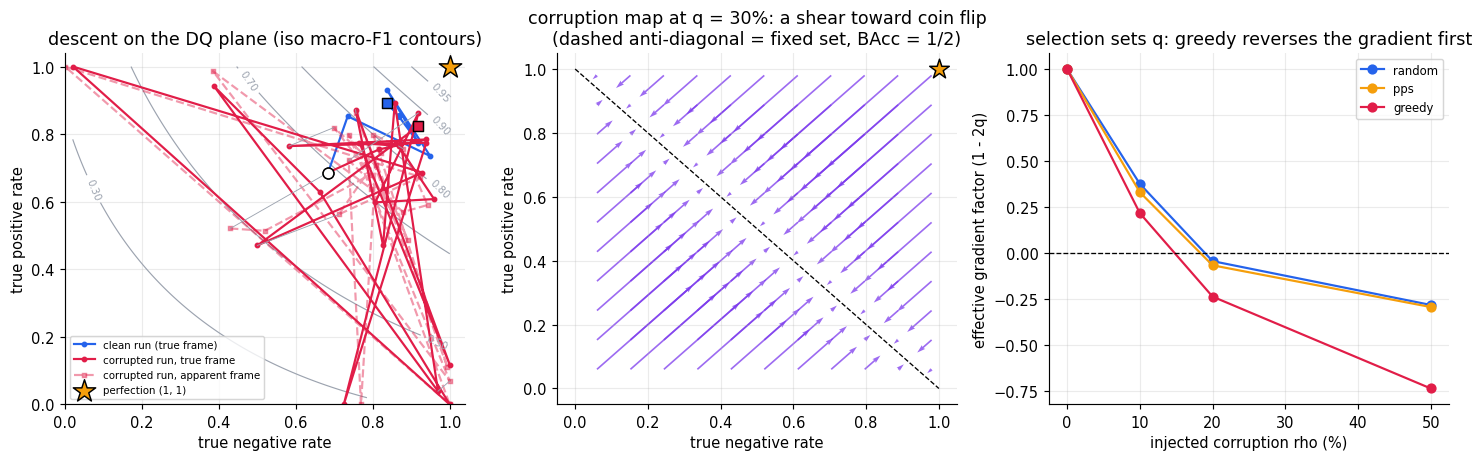

final positions (TNR, TPR): clean true (0.84, 0.89) | corrupted true (0.92, 0.82) | corrupted apparent (0.82, 0.74)


In [7]:
# 6. The decision quality plane
def rates_of(w, b, X, y):
    pred = np.where(X @ w + b >= 0, 1, -1)
    return float((pred[y == 1] == 1).mean()), float((pred[y == -1] == -1).mean())

def macro_f1_grid(tpr, tnr, pi=0.5):
    fpr = 1 - tnr; fnr = 1 - tpr
    Pp = pi * tpr / np.maximum(pi * tpr + (1 - pi) * fpr, 1e-9)
    F1p = 2 * Pp * tpr / np.maximum(Pp + tpr, 1e-9)
    Pn = (1 - pi) * tnr / np.maximum((1 - pi) * tnr + pi * fnr, 1e-9)
    F1n = 2 * Pn * tnr / np.maximum(Pn + tnr, 1e-9)
    return 0.5 * (F1p + F1n)

def plane_traj(H, frame='true'):
    if frame == 'true': idx, y = H['bench'], H['y_true']
    else:               idx, y = H['pool'][:300], H['y_lab']
    return np.array([rates_of(w, b, H['X'][idx], y[idx]) for w, b in H['w']])

H_cl = run_descent(rho=0.0)
H_cr = run_descent(rho=0.30, target='hard_aligned', gate='off')
T_cl = plane_traj(H_cl); T_tr = plane_traj(H_cr, 'true'); T_ap = plane_traj(H_cr, 'apparent')

gt, gn = np.meshgrid(np.linspace(0.02, 1, 220), np.linspace(0.02, 1, 220))
F = macro_f1_grid(gt, gn)
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.5))
ax = axes[0]
cs = ax.contour(gn, gt, F, levels=[0.3, 0.5, 0.7, 0.8, 0.9, 0.95], colors='#9ca3af', linewidths=0.8)
ax.clabel(cs, fmt='%.2f', fontsize=7)
ax.plot(T_cl[:, 1], T_cl[:, 0], 'o-', ms=3, c=COL['clean'], label='clean run (true frame)')
ax.plot(T_tr[:, 1], T_tr[:, 0], 'o-', ms=3, c=COL['c20'], label='corrupted run, true frame')
ax.plot(T_ap[:, 1], T_ap[:, 0], 's--', ms=3, c=COL['c20'], alpha=0.45, label='corrupted run, apparent frame')
for i in range(0, len(T_tr), 3):
    ax.plot([T_tr[i, 1], T_ap[i, 1]], [T_tr[i, 0], T_ap[i, 0]], c='#9ca3af', lw=0.6)
for T, cc in [(T_cl, COL['clean']), (T_tr, COL['c20'])]:
    ax.scatter(T[0, 1], T[0, 0], s=55, facecolors='white', edgecolors='k', zorder=6)
    ax.scatter(T[-1, 1], T[-1, 0], s=45, marker='s', c=cc, edgecolors='k', zorder=6)
ax.scatter([1], [1], marker='*', s=260, c='#f59e0b', edgecolors='k', zorder=5, label='perfection (1, 1)')
ax.set_xlabel('true negative rate'); ax.set_ylabel('true positive rate')
ax.set_xlim(0, 1.04); ax.set_ylim(0, 1.04)
ax.set_title('descent on the DQ plane (iso macro-F1 contours)')
ax.legend(fontsize=7, loc='lower left')
ax = axes[1]
r = 0.30
g = np.linspace(0.06, 0.98, 11); TP, TN = np.meshgrid(g, g)
ax.quiver(TN, TP, (1 - r) * TN + r * (1 - TP) - TN, (1 - r) * TP + r * (1 - TN) - TP,
          angles='xy', scale_units='xy', scale=1, width=0.0042, color='#7c3aed', alpha=0.75)
ax.plot([0, 1], [1, 0], 'k--', lw=0.9)
ax.scatter([1], [1], marker='*', s=200, c='#f59e0b', edgecolors='k', zorder=5)
ax.set_xlabel('true negative rate'); ax.set_ylabel('true positive rate')
ax.set_title('corruption map at q = 30%: a shear toward coin flip' + chr(10) + '(dashed anti-diagonal = fixed set, BAcc = 1/2)')
ax = axes[2]
piv = df.pivot(index='rho', columns='strategy', values='anchor_flip_share')
for strat in ['random', 'pps', 'greedy']:
    ax.plot(100 * piv.index, 1 - 2 * piv[strat], 'o-', c=COL[strat], label=strat)
ax.axhline(0, c='k', lw=0.9, ls='--')
ax.set_xlabel('injected corruption rho (%)'); ax.set_ylabel('effective gradient factor (1 - 2q)')
ax.set_title('selection sets q: greedy reverses the gradient first')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print('final positions (TNR, TPR): clean true (%.2f, %.2f) | corrupted true (%.2f, %.2f) | corrupted apparent (%.2f, %.2f)'
      % (T_cl[-1, 1], T_cl[-1, 0], T_tr[-1, 1], T_tr[-1, 0], T_ap[-1, 1], T_ap[-1, 0]))

## 6. The two failure modes under the microscope

**Case A (silencing).** Take the truly misaligned items (the policy genuinely fails there), flip their labels, and watch the anchor value collapse toward zero: the gradient is gone and the learning opportunity is missed.

**Case B (adversarial injection).** Flip a handful of easy aligned points. They become synthetic T1 anchors at the top of the queue; the descent direction swings toward them, and the boundary lurches through the clean region. The right panels show it two ways: the trajectory on the decision quality plane wanders instead of marching to the corner, and the accepted steps decorrelate from the true descent direction (their cosine collapses toward zero) where the clean run's steps stay aligned.

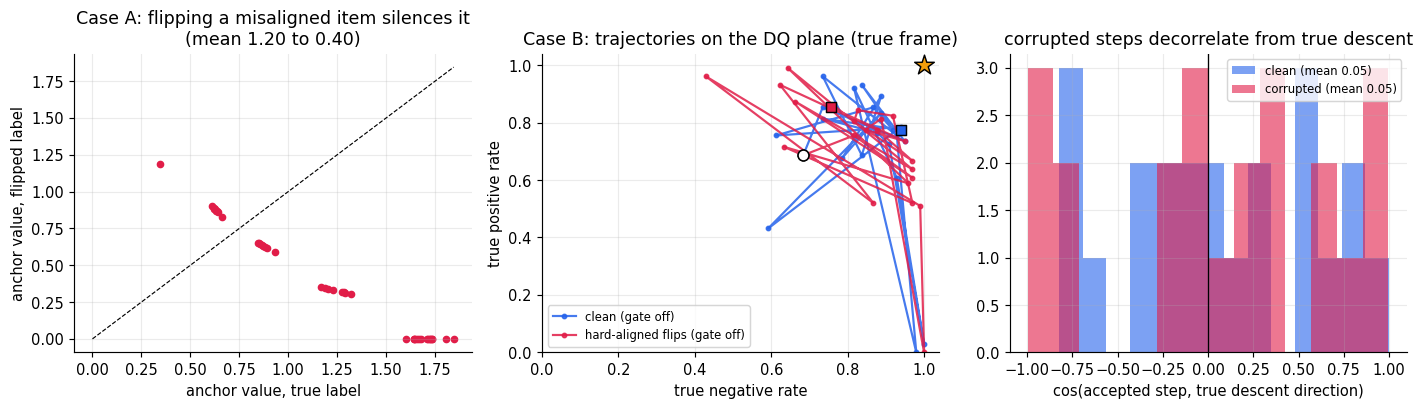

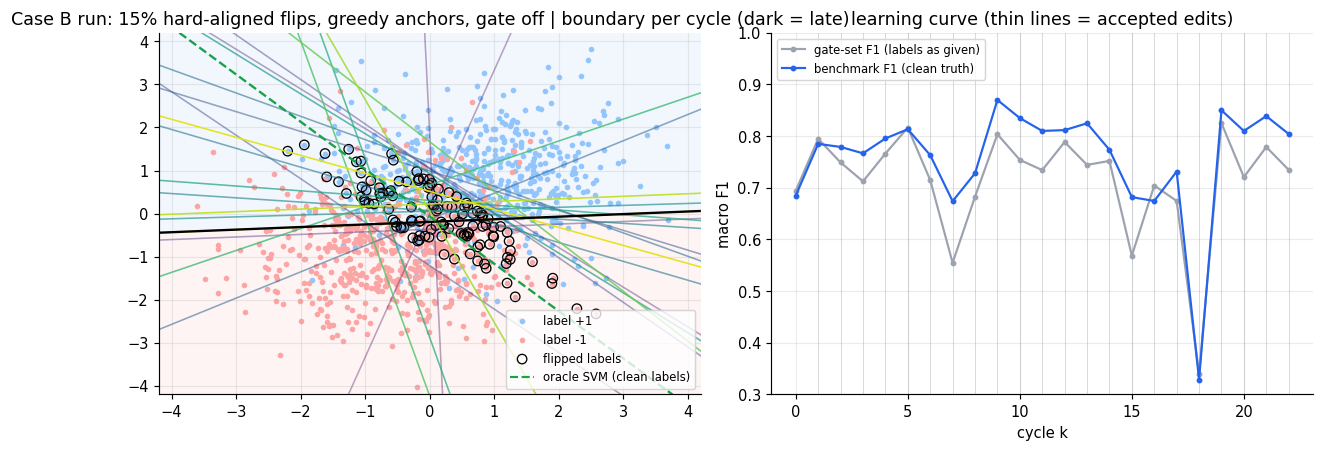

In [8]:
# 7. Case A: anchor collapse | Case B: chaotic directions
H0 = run_descent(rho=0.0)
X, y_true, st0 = H0['X'], H0['y_true'], H0['st0']
mis = np.where(st0['misal'])[0][:40]
y_flip = y_true.copy(); y_flip[mis] = -y_flip[mis]
v, c = H0['panel'].votes(np.array([1.0, -0.30]), 0.0, X, np.random.default_rng(5))
before = panel_stats(v, c, y_true)['anchor'][mis]
after  = panel_stats(v, c, y_flip)['anchor'][mis]

H0c = run_descent(rho=0.0, gate='off')
HB = run_descent(rho=0.15, target='hard_aligned', strategy='greedy', gate='off', seed=13)
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.0))
ax = axes[0]
ax.scatter(before, after, s=18, c='#e11d48')
lim = max(before.max(), 0.9)
ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
ax.set_xlabel('anchor value, true label'); ax.set_ylabel('anchor value, flipped label')
ax.set_title('Case A: flipping a misaligned item silences it\n(mean %.2f to %.2f)'
             % (before.mean(), after.mean()))
ax = axes[1]
for H, cc, lb in [(H0c, COL['clean'], 'clean (gate off)'), (HB, COL['c20'], 'hard-aligned flips (gate off)')]:
    T = plane_traj(H)
    ax.plot(T[:, 1], T[:, 0], 'o-', ms=3, c=cc, label=lb, alpha=0.85)
    ax.scatter(T[0, 1], T[0, 0], s=55, facecolors='white', edgecolors='k', zorder=6)
    ax.scatter(T[-1, 1], T[-1, 0], s=45, marker='s', c=cc, edgecolors='k', zorder=6)
ax.scatter([1], [1], marker='*', s=200, c='#f59e0b', edgecolors='k', zorder=5)
ax.set_xlabel('true negative rate'); ax.set_ylabel('true positive rate')
ax.set_xlim(0, 1.04); ax.set_ylim(0, 1.04); ax.legend(fontsize=8, loc='lower left')
ax.set_title('Case B: trajectories on the DQ plane (true frame)')
ax = axes[2]
def step_cosines(H):
    X, y, pool = H['X'], H['y_true'], H['pool']
    out = []
    for (wa, ba), (wb2, bb2), acc in zip(H['w'][:-1], H['w'][1:], H['accepted']):
        if not acc: continue
        dw = np.asarray(wb2) - np.asarray(wa)
        if np.linalg.norm(dw) < 1e-9: continue
        m = X[pool] @ np.asarray(wa) + ba
        grad = -(y[pool][:, None] * X[pool] / (1 + np.exp(y[pool] * m))[:, None]).mean(0)
        d = -grad
        out.append(float(dw @ d / (np.linalg.norm(dw) * np.linalg.norm(d) + 1e-12)))
    return np.array(out)
c0 = step_cosines(H0c); c1 = step_cosines(HB)
ax.hist(c0, bins=14, alpha=0.6, color=COL['clean'], label='clean (mean %.2f)' % c0.mean())
ax.hist(c1, bins=14, alpha=0.6, color=COL['c20'], label='corrupted (mean %.2f)' % c1.mean())
ax.axvline(0, c='k', lw=0.9)
ax.set_xlabel('cos(accepted step, true descent direction)')
ax.set_title('corrupted steps decorrelate from true descent')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
plot_run(HB, 'Case B run: 15% hard-aligned flips, greedy anchors, gate off')

## 7. The Lyapunov probe: different starting points, and what corruption does to the basin

A subtlety worth being honest about: in a stochastic discrete map, an infinitesimal start perturbation sits below the decoding-noise floor, so its growth measures noise, not dynamics. The operationally meaningful probe is macroscopic: **start two runs from widely different policies** (two boundaries about 90 degrees apart), share the seed and the corruption exactly (common $\\xi$), and ask whether the trajectories re-merge, with separation measured behaviorally: the flip rate between the two policies on the benchmark (Section 3 established the embedding as only a proxy for this). That is the "convergence with different starting points" question, and $\\hat\\lambda$ from C3 is its rate: negative means the basin pulls both starts to the same policy and the path is forgotten; near zero means the starts stay apart (no shared basin: frozen or wandering).

One instrument is not enough, and the sweep below shows why. $\\hat\\lambda$ certifies **reproducibility**; only the clean benchmark certifies **truth**. The measured taxonomy:

| regime | $\\hat\\lambda$ | honest F1 | reading |
|---|---|---|---|
| clean, any gate | $< 0$ | high | healthy: converges, and to the right place |
| heavy random corruption, gate off | $< 0$ | collapsed | **reproducibly wrong**: the map contracts onto a garbage attractor |
| targeted boundary corruption, gate off | rises through $0$ | degraded | **wandering**: the realistic corruption pattern is the one that destroys the basin |
| honest metric gate, rising $\\rho$ | $< 0$, weakening | protected | the trust region preserves contraction, then freezes: shielded but no longer learning |
| corrupted metric gate, heavy $\\rho$ | $\\to 0^+$ | degraded | the referee is corrupted too: the case for re-adjudicating evaluation splits |

D2 seed sweeps from a common start give the ensemble dispersion $\\sigma_k$ (C4), the randomized-path counterpart.

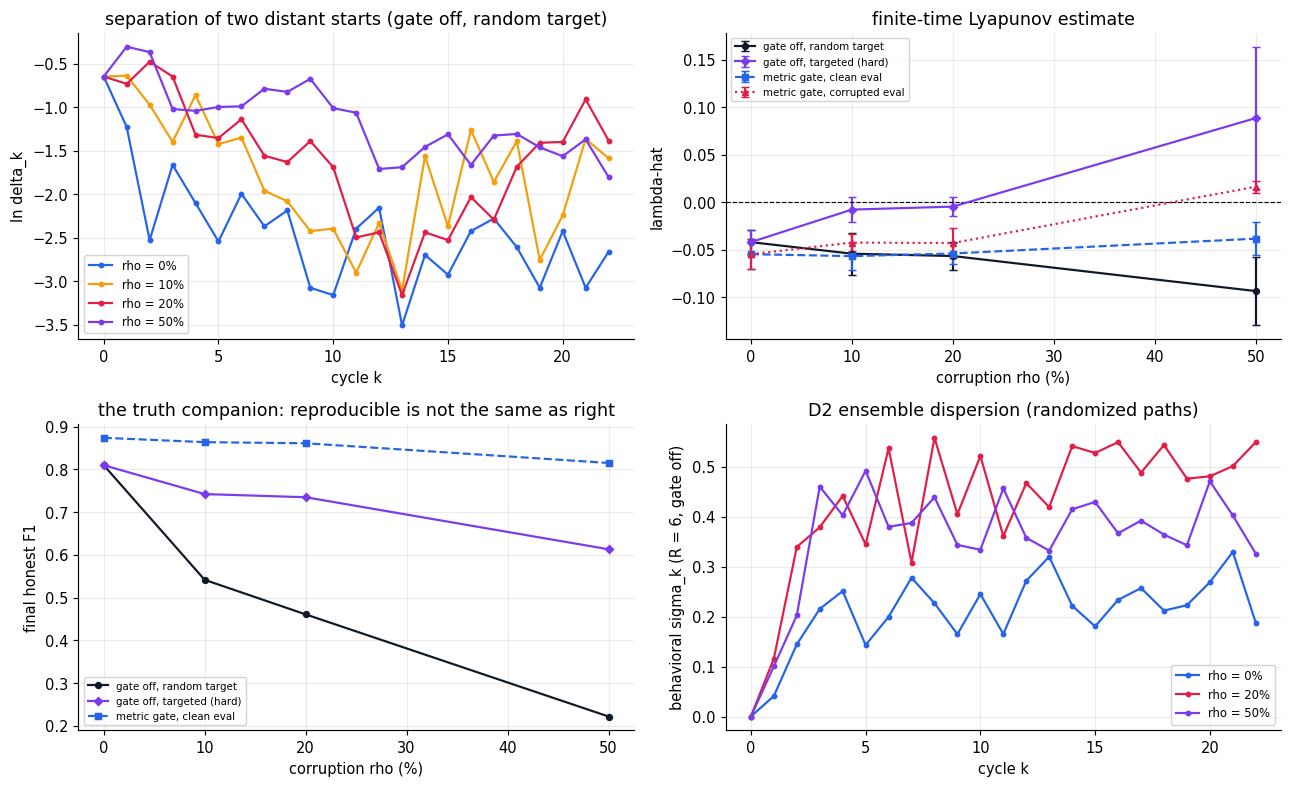

gate off, random target        {'0%': (-0.042, 0.81), '10%': (-0.054, 0.54), '20%': (-0.057, 0.46), '50%': (-0.094, 0.22)}
gate off, targeted (hard)      {'0%': (-0.042, 0.81), '10%': (-0.008, 0.74), '20%': (-0.005, 0.73), '50%': (0.088, 0.61)}
metric gate, clean eval        {'0%': (-0.055, 0.87), '10%': (-0.057, 0.86), '20%': (-0.054, 0.86), '50%': (-0.038, 0.82)}
metric gate, corrupted eval    {'0%': (-0.055, 0.87), '10%': (-0.043, 0.86), '20%': (-0.043, 0.86), '50%': (0.016, 0.61)}


In [9]:
# 8. Shadow pairs: lambda-hat and honest F1 across gates and corruption targets
def beh_dist(H1, H2):
    '''Panel-free behavioral separation: flip rate between the two policies on the
    benchmark, floored at half a percent. The primary metric per Section 3.'''
    X, idx = H1['X'], H1['bench']
    out = []
    for (w1, b1), (w2, b2) in zip(H1['w'], H2['w']):
        pa = np.where(X[idx] @ w1 + b1 >= 0, 1, -1)
        pb = np.where(X[idx] @ w2 + b2 >= 0, 1, -1)
        out.append(max(float((pa != pb).mean()), 5e-3))
    return np.array(out)

def lyap_fit(delta):
    d = np.maximum(np.asarray(delta, float), 1e-9)
    k = np.arange(len(d)); g = np.log(d)
    kk = max(int(np.argmax(d >= 0.8 * d.max())), 4) if d.max() > 2.5 * d[1] else len(d) - 1
    win = (k >= 1) & (k <= kk) & (d > 6e-3)
    if win.sum() < 3: win = (k >= 1) & (k <= kk)
    return float(np.polyfit(k[win], g[win], 1)[0])

def shadow(rho, gate, corrupt_gate, target='random', seeds=(13, 14, 15, 16)):
    slopes, cs, f1s = [], [], []
    for s in seeds:
        Ha = run_descent(rho=rho, seed=s, gate=gate, corrupt_gate=corrupt_gate, target=target,
                         corrupt_seed=101, w0=(1.0, -0.30))
        Hb = run_descent(rho=rho, seed=s, gate=gate, corrupt_gate=corrupt_gate, target=target,
                         corrupt_seed=101, w0=(-0.25, 1.00))
        d = beh_dist(Ha, Hb)
        slopes.append(lyap_fit(d)); cs.append(d)
        f1s.append(0.5 * (Ha['f1_bench'][-1] + Hb['f1_bench'][-1]))
    return slopes, np.mean(cs, axis=0), float(np.mean(f1s))

rhos = [0.0, 0.10, 0.20, 0.50]
arms = {'gate off, random target':   dict(gate='off',    corrupt_gate=False, target='random'),
        'gate off, targeted (hard)': dict(gate='off',    corrupt_gate=False, target='hard_aligned'),
        'metric gate, clean eval':   dict(gate='metric', corrupt_gate=False, target='random'),
        'metric gate, corrupted eval': dict(gate='metric', corrupt_gate=True, target='random')}
LAM = {a: {} for a in arms}; F1F = {a: {} for a in arms}; CURVES = {}
for a, kw in arms.items():
    for r in rhos:
        sl, cv, f1 = shadow(r, **kw)
        LAM[a][r] = sl; F1F[a][r] = f1
        if a == 'gate off, random target': CURVES[r] = cv

R = 6
disp = {}
for r in [0.0, 0.20, 0.50]:
    Hs = [run_descent(rho=r, seed=100 + i, gate='off', corrupt_seed=101) for i in range(R)]
    Xb, ib = Hs[0]['X'], Hs[0]['bench']
    sig = []
    for k in range(len(Hs[0]['w'])):
        preds = [np.where(Xb[ib] @ H['w'][k][0] + H['w'][k][1] >= 0, 1, -1) for H in Hs]
        ds = [float((preds[i] != preds[j]).mean()) for i in range(R) for j in range(i + 1, R)]
        sig.append(np.mean(ds))
    disp[r] = sig

fig, axes = plt.subplots(2, 2, figsize=(12.4, 7.6))
ax = axes[0, 0]
for r, cc in zip(rhos, [COL['clean'], COL['c10'], COL['c20'], COL['c50']]):
    ax.plot(np.log(np.maximum(CURVES[r], 1e-9)), 'o-', ms=3, c=cc, label='rho = %.0f%%' % (100 * r))
ax.set_xlabel('cycle k'); ax.set_ylabel('ln delta_k')
ax.set_title('separation of two distant starts (gate off, random target)'); ax.legend(fontsize=8)
mk = {'gate off, random target': ('o-', '#111827'), 'gate off, targeted (hard)': ('D-', COL['c50']),
      'metric gate, clean eval': ('s--', COL['clean']), 'metric gate, corrupted eval': ('^:', COL['c20'])}
ax = axes[0, 1]
for a in arms:
    mus = [np.mean(LAM[a][r]) for r in rhos]; ses = [np.std(LAM[a][r]) / 2 for r in rhos]
    ax.errorbar([100 * r for r in rhos], mus, yerr=ses, fmt=mk[a][0], c=mk[a][1], capsize=3, label=a, ms=4)
ax.axhline(0, c='k', lw=0.8, ls='--')
ax.set_xlabel('corruption rho (%)'); ax.set_ylabel('lambda-hat')
ax.set_title('finite-time Lyapunov estimate'); ax.legend(fontsize=7)
ax = axes[1, 0]
for a in ['gate off, random target', 'gate off, targeted (hard)', 'metric gate, clean eval']:
    ax.plot([100 * r for r in rhos], [F1F[a][r] for r in rhos], mk[a][0], c=mk[a][1], label=a, ms=4)
ax.set_xlabel('corruption rho (%)'); ax.set_ylabel('final honest F1')
ax.set_title('the truth companion: reproducible is not the same as right'); ax.legend(fontsize=7)
ax = axes[1, 1]
for r, cc in zip([0.0, 0.20, 0.50], [COL['clean'], COL['c20'], COL['c50']]):
    ax.plot(disp[r], 'o-', ms=3, c=cc, label='rho = %.0f%%' % (100 * r))
ax.set_xlabel('cycle k'); ax.set_ylabel('behavioral sigma_k (R = %d, gate off)' % R)
ax.set_title('D2 ensemble dispersion (randomized paths)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for a in arms:
    print(a.ljust(30), {('%.0f%%' % (100 * r)): (round(float(np.mean(LAM[a][r])), 3), round(F1F[a][r], 2)) for r in rhos})

## 8. Interactive panel

Sliders for $\rho$, corruption target, sampling strategy, gate, and seed. Requires ipywidgets; without it the cell renders one static default so the notebook still executes end to end.

ipywidgets not installed: rendering one static default (pip install ipywidgets to get sliders)


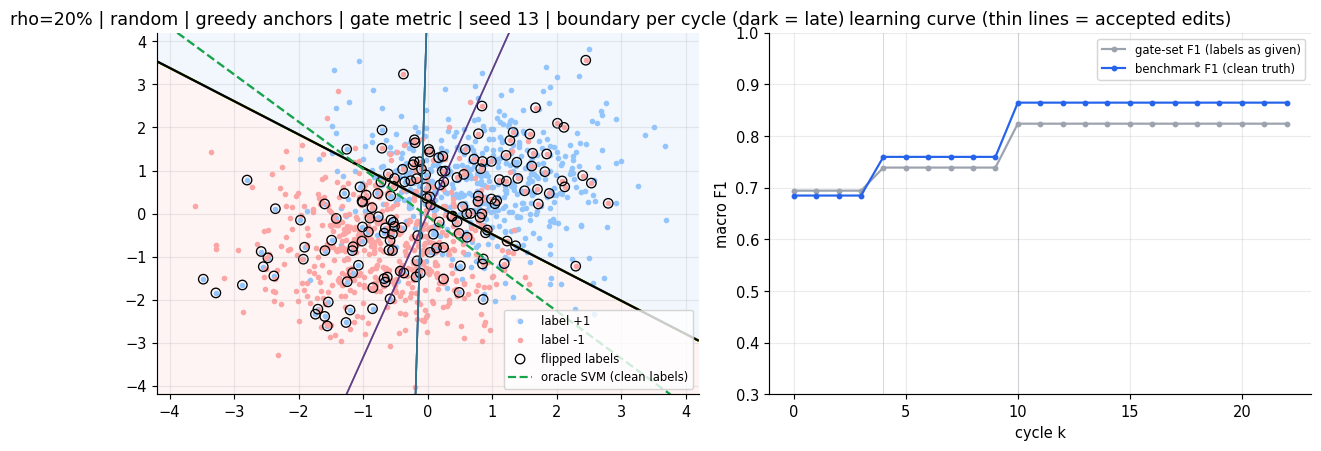

final honest F1 = 0.865 | accepted 2 | mean anchor corruption share = 0.62


In [10]:
# 9. Interactive exploration (optional ipywidgets)
def explore(rho=0.2, target='random', strategy='greedy', gate='metric', seed=13):
    H = run_descent(rho=rho, target=target, strategy=strategy, gate=gate, seed=seed)
    plot_run(H, 'rho=%.0f%% | %s | %s anchors | gate %s | seed %d'
             % (100 * rho, target, strategy, gate, seed))
    print('final honest F1 = %.3f | accepted %d | mean anchor corruption share = %.2f'
          % (H['f1_bench'][-1], sum(H['accepted']), float(np.mean(H['flip_share']))))

try:
    from ipywidgets import interact, FloatSlider, Dropdown, IntSlider
    interact(explore,
             rho=FloatSlider(value=0.2, min=0.0, max=0.6, step=0.05),
             target=Dropdown(options=['random', 'misaligned_t12', 'hard_aligned']),
             strategy=Dropdown(options=['greedy', 'pps', 'random']),
             gate=Dropdown(options=['metric', 'off']),
             seed=IntSlider(value=13, min=1, max=99))
except ImportError:
    print('ipywidgets not installed: rendering one static default (pip install ipywidgets to get sliders)')
    explore()

## 9. Load real runs: clean versus corrupted arms

The harness exports one JSON per run. Expected schema (all fields the demo UI already records or can trivially add):

```json
{
  "run_id": "r12", "arm": "corrupt_20", "rho": 0.20,
  "corrupt_target": "random", "strategy": "greedy", "seed": 13,
  "cycles": [
    {"k": 0, "version": "v0.1", "accepted": true,
     "f1_test": 0.55, "f1_benchmark": 0.52,
     "tpr_true": 0.61, "tnr_true": 0.58, "tpr_apparent": 0.60, "tnr_apparent": 0.57,
     "mean_g_anchors": 0.41, "anchor_flip_share": 0.30,
     "policy_chars": 1234, "policy_text": "...", "embedding": null}
  ]
}
```

Drop files into `./rush_runs/`. If `embedding` is null the loader embeds `policy_text` with the same TF-IDF stand-in (on production data, swap in the frozen embedder and record its version). If the folder is empty, the cell writes demo exports from the simulator so everything below runs either way. Four readouts: **learning curves** per arm, **gradient descent** (mean anchor $\overline{|g|}$ and the per-cycle text step $d_{emb}(G_k, G_{k-1})$), **distances in policy document space** ($\delta_k$ between the clean run and each corrupted twin, plus the pairwise final-policy heatmap), and **the decision quality plane** (two-frame trajectories per run, the standard instrument of Section 5).

no exports found: writing demo exports from the simulator


loaded 5 runs: ['r_c10', 'r_c20', 'r_c50', 'r_clean_a', 'r_clean_b']


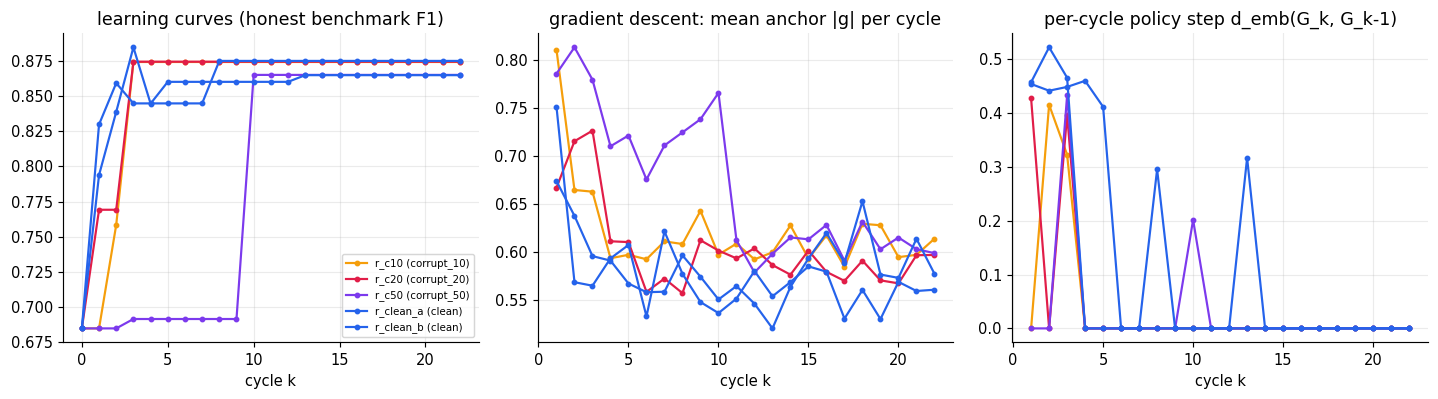

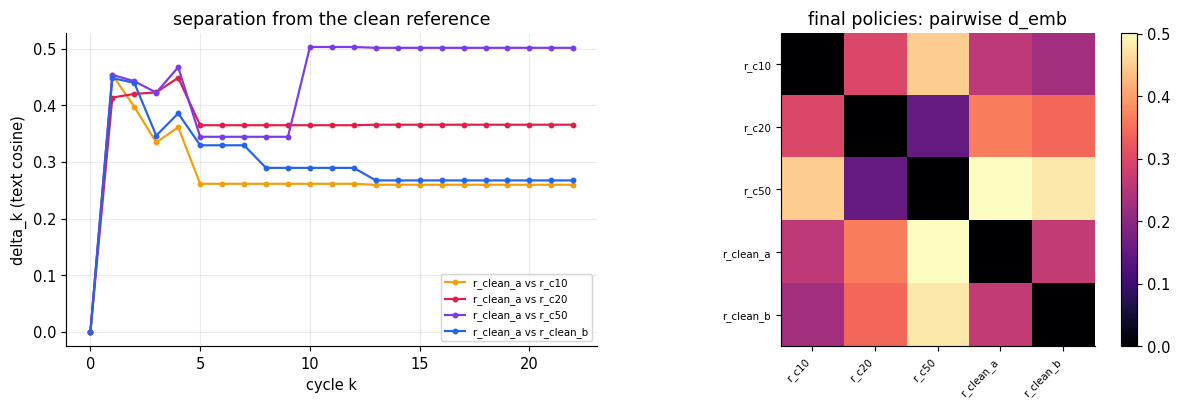

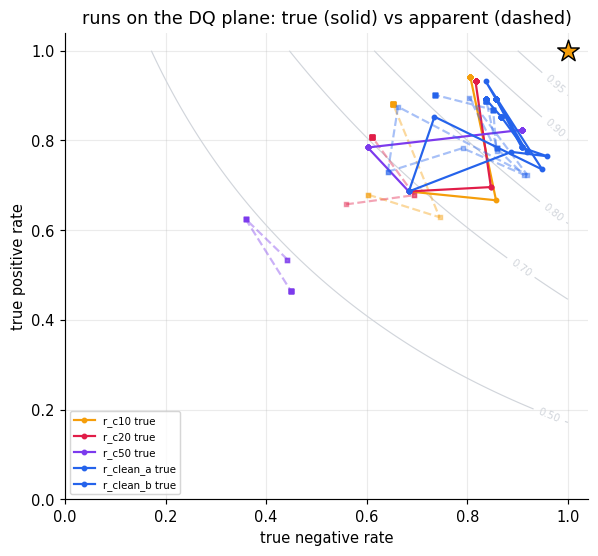

In [11]:
# 10. Loader and cross-arm plots
RUN_DIR = 'rush_runs'

def export_run(H, run_id, arm, rho, path=RUN_DIR):
    os.makedirs(path, exist_ok=True)
    def plane(i):
        w, b = H['w'][i]
        tt, nt = rates_of(w, b, H['X'][H['bench']], H['y_true'][H['bench']])
        pa = H['pool'][:300]
        ta, na = rates_of(w, b, H['X'][pa], H['y_lab'][pa])
        return dict(tpr_true=round(tt, 4), tnr_true=round(nt, 4),
                    tpr_apparent=round(ta, 4), tnr_apparent=round(na, 4))
    cyc = [dict(k=0, version='v0.1', accepted=True,
                f1_test=float(macro_f1(*H['w'][0], H['X'][H['test']], H['y_lab'][H['test']])),
                f1_benchmark=float(H['f1_bench0']), mean_g_anchors=None,
                anchor_flip_share=None, policy_chars=len(H['text'][0]),
                policy_text=H['text'][0], embedding=None, **plane(0))]
    for i, k in enumerate(H['k']):
        cyc.append(dict(k=int(k), version='v%d' % k, accepted=bool(H['accepted'][i]),
                        f1_test=float(H['f1_test'][i]), f1_benchmark=float(H['f1_bench'][i]),
                        mean_g_anchors=float(H['g_anchor'][i]),
                        anchor_flip_share=float(H['flip_share'][i]),
                        policy_chars=len(H['text'][i + 1]), policy_text=H['text'][i + 1],
                        embedding=None, **plane(i + 1)))
    doc = dict(run_id=run_id, arm=arm, rho=rho, corrupt_target='random',
               strategy='greedy', seed=13, cycles=cyc)
    with open(os.path.join(path, run_id + '.json'), 'w') as f: json.dump(doc, f)

def load_runs(path=RUN_DIR):
    files = sorted(glob.glob(os.path.join(path, '*.json')))
    if not files:
        print('no exports found: writing demo exports from the simulator')
        for rid, arm, r in [('r_clean_a', 'clean', 0.0), ('r_clean_b', 'clean', 0.0),
                            ('r_c10', 'corrupt_10', 0.10), ('r_c20', 'corrupt_20', 0.20),
                            ('r_c50', 'corrupt_50', 0.50)]:
            sd = 13 if rid != 'r_clean_b' else 14
            export_run(run_descent(rho=r, seed=sd, corrupt_seed=101), rid, arm, r)
        files = sorted(glob.glob(os.path.join(path, '*.json')))
    runs = [json.load(open(f)) for f in files]
    print('loaded %d runs: %s' % (len(runs), [r['run_id'] for r in runs]))
    return runs

def run_frame(run):
    df = pd.DataFrame(run['cycles'])
    df['run_id'], df['arm'], df['rho'] = run['run_id'], run['arm'], run['rho']
    return df

runs = load_runs()
frames = pd.concat([run_frame(r) for r in runs], ignore_index=True)

# shared embedding space across every version of every run
all_texts, owner = [], []
for r in runs:
    for cyc in r['cycles']:
        all_texts.append(cyc['policy_text']); owner.append((r['run_id'], cyc['k']))
tv = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))
EMB = tv.fit_transform(all_texts)
pos = {o: i for i, o in enumerate(owner)}
def emb_of(run_id, k): return EMB[pos[(run_id, k)]]
def d_emb_pair(r1, k1, r2, k2): return float(cosine_distances(emb_of(r1, k1), emb_of(r2, k2))[0, 0])

armcol = {'clean': COL['clean'], 'corrupt_10': COL['c10'], 'corrupt_20': COL['c20'], 'corrupt_50': COL['c50']}
fig, axes = plt.subplots(1, 3, figsize=(13.8, 3.9))
for rid, g in frames.groupby('run_id'):
    cc = armcol.get(g['arm'].iloc[0], '#111827')
    axes[0].plot(g.k, g.f1_benchmark, 'o-', ms=3, c=cc, label='%s (%s)' % (rid, g['arm'].iloc[0]))
    axes[1].plot(g.k[1:], g.mean_g_anchors[1:], 'o-', ms=3, c=cc)
    steps = [d_emb_pair(rid, k0, rid, k1) for k0, k1 in zip(g.k[:-1], g.k[1:])]
    axes[2].plot(g.k[1:], steps, 'o-', ms=3, c=cc)
axes[0].set_title('learning curves (honest benchmark F1)'); axes[0].set_xlabel('cycle k')
axes[0].legend(fontsize=7)
axes[1].set_title('gradient descent: mean anchor |g| per cycle'); axes[1].set_xlabel('cycle k')
axes[2].set_title('per-cycle policy step d_emb(G_k, G_k-1)'); axes[2].set_xlabel('cycle k')
plt.tight_layout(); plt.show()

# delta_k between the clean reference and each corrupted twin, plus the final heatmap
ref = [r['run_id'] for r in runs if r['arm'] == 'clean'][0]
Kmax = int(frames.k.max())
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))
for r in runs:
    if r['run_id'] == ref: continue
    dk = [d_emb_pair(ref, k, r['run_id'], k) for k in range(Kmax + 1)]
    axes[0].plot(dk, 'o-', ms=3, c=armcol.get(r['arm'], '#111827'), label='%s vs %s' % (ref, r['run_id']))
axes[0].set_xlabel('cycle k'); axes[0].set_ylabel('delta_k (text cosine)')
axes[0].set_title('separation from the clean reference'); axes[0].legend(fontsize=7)
ids = [r['run_id'] for r in runs]
Mx = np.array([[d_emb_pair(a, Kmax, b, Kmax) for b in ids] for a in ids])
im = axes[1].imshow(Mx, cmap='magma'); plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_xticks(range(len(ids)), ids, rotation=45, ha='right', fontsize=7)
axes[1].set_yticks(range(len(ids)), ids, fontsize=7); axes[1].grid(False)
axes[1].set_title('final policies: pairwise d_emb')
plt.tight_layout(); plt.show()

if 'tpr_true' in frames.columns:
    fig, ax = plt.subplots(figsize=(5.8, 5.4))
    gt2, gn2 = np.meshgrid(np.linspace(0.02, 1, 200), np.linspace(0.02, 1, 200))
    cs = ax.contour(gn2, gt2, macro_f1_grid(gt2, gn2), levels=[0.5, 0.7, 0.8, 0.9, 0.95],
                    colors='#d1d5db', linewidths=0.8)
    ax.clabel(cs, fmt='%.2f', fontsize=7)
    for rid, g in frames.groupby('run_id'):
        cc = armcol.get(g['arm'].iloc[0], '#111827')
        ax.plot(g.tnr_true, g.tpr_true, 'o-', ms=3, c=cc, label='%s true' % rid)
        ax.plot(g.tnr_apparent, g.tpr_apparent, 's--', ms=2.5, c=cc, alpha=0.4)
    ax.scatter([1], [1], marker='*', s=240, c='#f59e0b', edgecolors='k', zorder=5)
    ax.set_xlim(0, 1.04); ax.set_ylim(0, 1.04)
    ax.set_xlabel('true negative rate'); ax.set_ylabel('true positive rate')
    ax.set_title('runs on the DQ plane: true (solid) vs apparent (dashed)')
    ax.legend(fontsize=7, loc='lower left'); plt.tight_layout(); plt.show()
else:
    print('these exports predate the plane fields: add tpr/tnr per cycle to enable the DQ plane readout')

## 10. Takeaways, and what lands in the harness

1. **Corruption is asymmetric.** Silencing (Case A) quietly removes true gradient mass; adversarial injection (Case B) actively steers the descent wrong, and importance-weighted selection concentrates it: the anchor corruption share runs well above $\rho$ under greedy selection. Random and PPS sampling are measurably more robust, at the cost of learning speed on clean data: the robustness/speed trade is now a measured curve, not an opinion.
2. **The Lyapunov instrument certifies reproducibility; only the clean benchmark certifies truth.** Clean runs contract: widely different starts re-merge and the path is forgotten. Heavy random corruption still contracts, onto a garbage attractor: reproducibly wrong. Targeted boundary corruption (the realistic pattern) is what destroys the basin: $\hat\lambda \to 0$ and different starts never re-merge. An honest metric gate preserves contraction at moderate $\rho$ and freezes the map at heavy $\rho$ (shielded but no longer learning: re-adjudication is the only recovery), and corrupting the gate labels hands the instability back.
3. **The document vector space is a good trajectory metric with known caveats**: pin the embedder and the render, calibrate against $d_{beh}$, and treat behavioral equivalence as the ground truth of "same policy."
4. **Into the product**: the run form gains a corruption knob ($\rho$, target, scope) recorded on the manifest (X11); re-adjudication (Section 5.10) is the recovery arm: corrupt, then re-adjudicate the top of the queue and measure how much of the honest lift returns; the non-perfect single-label confidence $p_{human} \approx 0.17$ at $N = 1$ is the standing hedge; and evaluation splits get the same treatment, since a corrupted gate set corrupts every accept decision.

5. **The decision quality plane removes the embedding from the optimization story.** Every policy sits at $(TNR, TPR)$; the gap to $(1,1)$ is the loss $(FPR, FNR)$; corruption is an affine shear toward coin flip with gradient factor $(1 - 2q)$ and a sign flip at $q = 1/2$, where $q$ is the anchor corruption share that selection, not injection, determines. Objective one (DQ) lives entirely on this plane. Objective two (an artifact that generalizes and helps every decider) is what $d_{beh}$, the transfer probes, and parsimony are for; the embedding stays as their cheap logging proxy.

Export schema, corruption formalism, and the experiment grid live in the design doc: Sections 5.12 and 5.13 and Section 9.13 (X11).